## 1. Install Dependencies

In [1]:
!pip install transformers torch torchvision Pillow faiss-cpu sentence-transformers pymupdf python-dotenv pyyaml tqdm numpy --quiet

## 2. Imports & Config

In [2]:
import json, os
from pathlib import Path
import numpy as np
import faiss
import yaml
import torch
from PIL import Image
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

load_dotenv(dotenv_path=Path("..") / ".env")

BASE_DIR      = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
IMAGE_DIR     = PROCESSED_DIR / "images"
VECTOR_DIR    = PROCESSED_DIR / "vectors"
EXPERIMENTS   = BASE_DIR / "experiments"
VECTOR_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / "configs" / "config.yaml") as f:
    config = yaml.safe_load(f)

TOP_K       = config.get("top_k", 5)
EMBED_MODEL = config.get("embed_model", "all-MiniLM-L6-v2")
CLIP_MODEL  = config.get("clip_model", "openai/clip-vit-base-patch32")
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"✅ Config loaded")
print(f"   Text model : {EMBED_MODEL}")
print(f"   CLIP model : {CLIP_MODEL}")
print(f"   Device     : {DEVICE}")

✅ Config loaded
   Text model : all-MiniLM-L6-v2
   CLIP model : openai/clip-vit-base-patch32
   Device     : cpu


## 3. Load Text Index from Notebook 02
Reuse the FAISS index and chunk metadata already built — no recomputation needed.

In [3]:
with open(VECTOR_DIR / "text_chunks.json") as f:
    text_chunks = json.load(f)

text_index   = faiss.read_index(str(VECTOR_DIR / "text_index.faiss"))
text_embedder = SentenceTransformer(EMBED_MODEL)

print(f"✅ Text index loaded")
print(f"   Chunks  : {len(text_chunks)}")
print(f"   Vectors : {text_index.ntotal}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Text index loaded
   Chunks  : 235
   Vectors : 235


## 4. Load CLIP Model
`clip-vit-base-patch32` encodes both images and text into the **same 512-dim space** — enabling cross-modal retrieval (text query → relevant images).

In [4]:
print(f"🔄 Loading CLIP: {CLIP_MODEL}")
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model.eval()
print(f"✅ CLIP loaded on {DEVICE}")

🔄 Loading CLIP: openai/clip-vit-base-patch32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ CLIP loaded on cpu


## 5. Embed Page Images with CLIP
Each scanned page PNG → CLIP vision encoder → 512-dim vector.

In [5]:
def embed_images_clip(image_dir, clip_model, clip_processor, device, batch_size=16):
    image_paths = sorted(list(Path(image_dir).rglob("*.png")))
    image_paths = [p for p in image_paths if "page_render_" not in p.name]
    print(f"📷 Found {len(image_paths)} images")

    all_embeddings, image_metadata = [], []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Embedding images"):
        batch_paths = image_paths[i:i+batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = clip_processor(images=images, return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            outputs = clip_model.vision_model(**inputs)
            feats   = clip_model.visual_projection(outputs.pooler_output)
            feats   = feats / feats.norm(dim=-1, keepdim=True)

        all_embeddings.append(feats.cpu().numpy())

        for p in batch_paths:
            pdf_stem = p.parent.name
            page_num = int(p.stem.split("_")[-1])
            image_metadata.append({
                "chunk_id"  : f"{pdf_stem}_img_p{page_num}",
                "source"    : pdf_stem + ".pdf",
                "page"      : page_num,
                "type"      : "image",
                "image_path": str(p)
            })

    return np.vstack(all_embeddings).astype("float32"), image_metadata

image_embeddings, image_chunks = embed_images_clip(IMAGE_DIR, clip_model, clip_processor, DEVICE)
print(f"\n✅ Image embeddings: {image_embeddings.shape}")

📷 Found 156 images


Embedding images: 100%|██████████| 10/10 [00:05<00:00,  1.91it/s]


✅ Image embeddings: (156, 512)


## 6. Build & Save CLIP Image FAISS Index

In [6]:
dim = image_embeddings.shape[1]  # 512 for CLIP ViT-B/32
image_index = faiss.IndexFlatIP(dim)
image_index.add(image_embeddings)

faiss.write_index(image_index, str(VECTOR_DIR / "image_index.faiss"))
with open(VECTOR_DIR / "image_chunks.json", "w") as f:
    json.dump(image_chunks, f, indent=2)

print(f"✅ Image FAISS index built — {image_index.ntotal} vectors @ {dim} dims")
print(f"💾 Saved: image_index.faiss + image_chunks.json")

✅ Image FAISS index built — 156 vectors @ 512 dims
💾 Saved: image_index.faiss + image_chunks.json


## 7. Retrieval Functions
- `retrieve_text` — sentence-transformers → text FAISS
- `embed_query_clip` / `retrieve_images` — CLIP text encoder → image FAISS (cross-modal)
- `multimodal_retrieve` — merges both, re-ranks by weighted score

In [7]:
def retrieve_text(query, text_index, text_chunks, text_embedder, top_k=5):
    q_emb = text_embedder.encode([query], convert_to_numpy=True)
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    scores, indices = text_index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        r = dict(text_chunks[idx])
        r["type"]  = "text"
        r["score"] = round(float(score), 4)
        results.append(r)
    return results

def embed_query_clip(query, clip_model, clip_processor, device):
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model.text_model(**inputs)
        feats   = clip_model.text_projection(outputs.pooler_output)
        feats   = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

def retrieve_images(query, image_index, image_chunks, clip_model, clip_processor, device, top_k=3):
    q_emb = embed_query_clip(query, clip_model, clip_processor, device)
    scores, indices = image_index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        r = dict(image_chunks[idx])
        r["score"] = round(float(score), 4)
        results.append(r)
    return results

def multimodal_retrieve(query, top_k=5, text_weight=0.6, image_weight=0.4,
                        guaranteed_images=2):
    """
    Unified retriever. Always returns at least `guaranteed_images` image results
    alongside text — needed because CLIP scores are inherently lower than
    text-text cosine scores and would otherwise be buried in ranking.
    """
    t_results = retrieve_text(query, text_index, text_chunks, text_embedder,
                              top_k=top_k - guaranteed_images)
    i_results = retrieve_images(query, image_index, image_chunks,
                                clip_model, clip_processor, DEVICE,
                                top_k=guaranteed_images)

    for r in t_results: r["weighted_score"] = r["score"] * text_weight
    for r in i_results: r["weighted_score"] = r["score"] * image_weight

    return sorted(t_results + i_results,
                  key=lambda x: x["weighted_score"], reverse=True)

print("✅ Retrieval functions defined")

✅ Retrieval functions defined


## 8. Multimodal Retrieval Demo
Test the unified retriever and visualize retrieved images.

🔍 Query: How does federated learning aggregate model updates?

Rank  Type     Score    Source               Preview
--------------------------------------------------------------------------------
  1    text     0.3589   Sample_2.pdf         18336 N. Chaurasia et al. 1 3 average pooling, and
  2    text     0.3475   Sample_2.pdf         18343 1 3 A federated learning approach to network
  3    text     0.3118   Sample_5.pdf         Fig. 8, and deep neural networks to increase the s
  4    image    0.1180   Sample_3.pdf         ed\images\Sample_3\Sample_3_page_010.png
  5    image    0.1179   Sample_3.pdf         ed\images\Sample_3\Sample_3_page_007.png


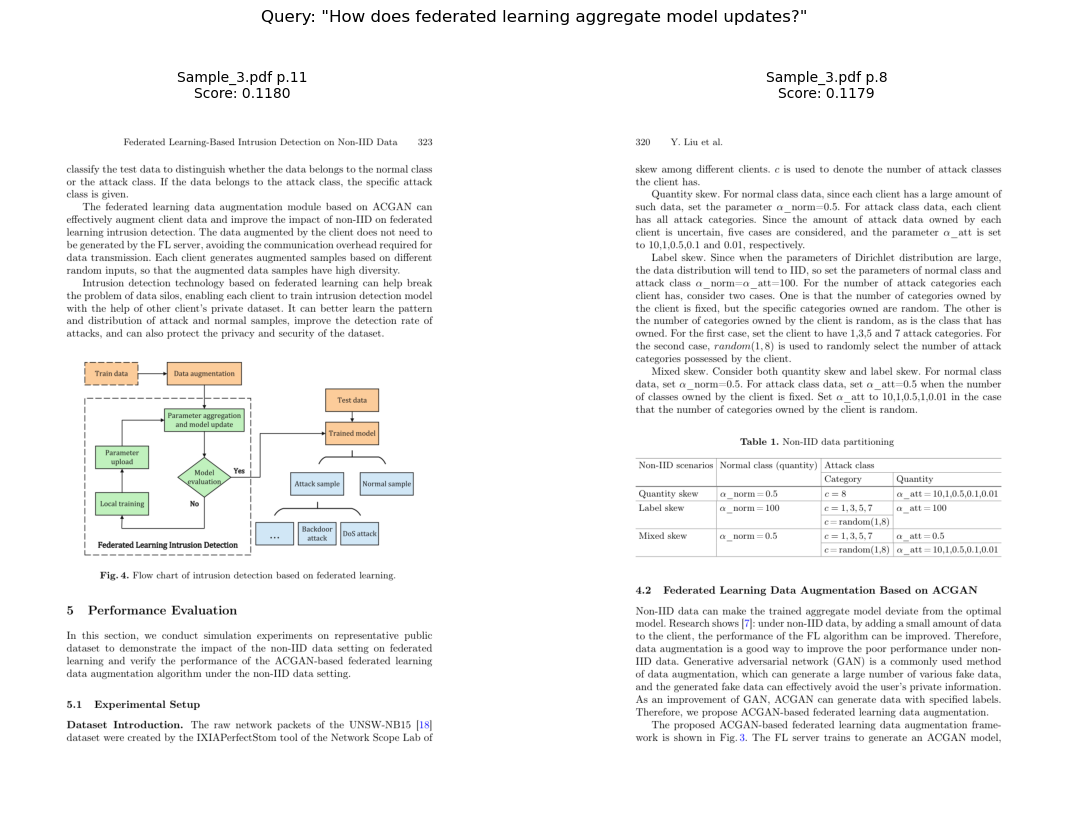

In [8]:
def visualize_image_results(query, results, max_images=2):
    image_results = [r for r in results if r.get("type") == "image"][:max_images]
    if not image_results:
        print("No image results")
        return
    fig, axes = plt.subplots(1, len(image_results), figsize=(6 * len(image_results), 8))
    if len(image_results) == 1:
        axes = [axes]
    for ax, r in zip(axes, image_results):
        ax.imshow(mpimg.imread(r["image_path"]))
        ax.set_title(f"{r['source']} p.{r['page']+1}\nScore: {r['weighted_score']:.4f}",
                     fontsize=10)
        ax.axis("off")
    plt.suptitle(f'Query: "{query}"', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Run demo
query   = "How does federated learning aggregate model updates?"
results = multimodal_retrieve(query, top_k=5)

print(f"🔍 Query: {query}\n")
print(f"{'Rank':<5} {'Type':<8} {'Score':<8} {'Source':<20} Preview")
print("-" * 80)
for i, r in enumerate(results):
    preview = r.get("text", "")[:50] if r["type"] == "text" else r["image_path"][-40:]
    print(f"  {i+1:<4} {r['type']:<8} {r['weighted_score']:<8.4f} {r['source']:<20} {preview}")

visualize_image_results(query, results)

## 9. Save Experiment Results

In [9]:
log = {
    "notebook"            : "03_multimodal_extension",
    "clip_model"          : CLIP_MODEL,
    "text_model"          : EMBED_MODEL,
    "device"              : DEVICE,
    "text_chunks"         : len(text_chunks),
    "image_chunks"        : len(image_chunks),
    "image_embedding_dim" : int(image_embeddings.shape[1]),
    "text_weight"         : 0.6,
    "image_weight"        : 0.4,
    "guaranteed_images"   : 2,
    "notes": (
        "CLIP ViT-B/32 image embeddings. "
        "Guaranteed image slots needed — CLIP scores inherently lower than text-text cosine. "
        "Next: wire multimodal_retrieve() into src/pipeline/rag_pipeline.py + FastAPI."
    )
}

with open(EXPERIMENTS / "03_multimodal_extension.json", "w") as f:
    json.dump(log, f, indent=2)

print("✅ Saved to experiments/03_multimodal_extension.json")
print(json.dumps(log, indent=2))
print("\n➡️  Next: src/pipeline/rag_pipeline.py + FastAPI endpoint")

✅ Saved to experiments/03_multimodal_extension.json
{
  "notebook": "03_multimodal_extension",
  "clip_model": "openai/clip-vit-base-patch32",
  "text_model": "all-MiniLM-L6-v2",
  "device": "cpu",
  "text_chunks": 235,
  "image_chunks": 156,
  "image_embedding_dim": 512,
  "text_weight": 0.6,
  "image_weight": 0.4,
  "guaranteed_images": 2,
  "notes": "CLIP ViT-B/32 image embeddings. Guaranteed image slots needed \u2014 CLIP scores inherently lower than text-text cosine. Next: wire multimodal_retrieve() into src/pipeline/rag_pipeline.py + FastAPI."
}

➡️  Next: src/pipeline/rag_pipeline.py + FastAPI endpoint


In [10]:
import shutil
from pathlib import Path

base     = Path("..")
vec_dir  = base / "data" / "processed" / "vectors"

text_dir  = vec_dir / "text"
image_dir = vec_dir / "image"
text_dir.mkdir(exist_ok=True)
image_dir.mkdir(exist_ok=True)

shutil.copy(vec_dir / "text_index.faiss",  text_dir / "index.faiss")
shutil.copy(vec_dir / "text_chunks.json",  text_dir / "metadata.json")
shutil.copy(vec_dir / "image_index.faiss", image_dir / "index.faiss")
shutil.copy(vec_dir / "image_chunks.json", image_dir / "metadata.json")

print("✅ Done!")
for f in sorted(vec_dir.rglob("*.faiss")) + sorted(vec_dir.rglob("*.json")):
    print(f"   {f.relative_to(vec_dir)}")

✅ Done!
   image\index.faiss
   image_index.faiss
   text\index.faiss
   text_index.faiss
   image\metadata.json
   image_chunks.json
   text\metadata.json
   text_chunks.json
